# Building a Blend-Severity Classifier — the Basics

This notebook builds a small image classifier **from scratch**, step by step, so you can
see every piece: the data, the network, the training loop, and how to read the results.

**The task:** each image is a 64x64, 3-band (g/r/i) cutout centered on one detected
galaxy. Some cutouts show a single isolated galaxy; others show a galaxy overlapping
with a neighbor. We classify each cutout into one of 4 ordered severity classes:

1. **Clean / isolated** — no visible neighbor
2. **Moderate blend** — a neighbor overlaps but the two are separable
3. **Severe blend** — heavy overlap, hard to separate
4. **Ambiguous overlap** — unclear if this is 1 or 2 objects

**How to use this notebook:** run all the cells top to bottom once to see it work.
Then go back to the **Settings** cell (Section 1), change one thing, and re-run
everything below it (`Kernel -> Restart Kernel and Run All Cells` is the safest way).
Section 9, at the very end, has a list of specific things to try.

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, cohen_kappa_score, confusion_matrix,
)
from torch.utils.data import DataLoader, WeightedRandomSampler

# this notebook lives in notebooks/, so the repo root is one level up
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from seed_classifier.data.dataset import (
    BlendCutoutDataset, class_sample_weights, compute_norm_stats, scene_split,
)

NUM_CLASSES = 4
CLASS_NAMES = ["clean", "moderate", "severe", "ambiguous"]

DATA_DIR = os.path.join(REPO_ROOT, "data", "sim", "run001")

## 1. Settings

Everything you can change lives in this one dictionary. Change a value, re-run this
cell and everything below it, and see what happens to the results in Section 8.

In [2]:
CONFIG = {
    # -- data --
    "val_frac": 0.2,   # fraction of scenes held out for validation
    "seed": 0,         # random seed, for reproducibility

    # -- network architecture --
    "num_conv_blocks": 3,  # how many (conv -> batchnorm -> relu -> pool) blocks to stack. try 2-5.
    "base_channels": 16,   # filters in the first conv block (doubles every block after that)
    "fc_hidden": 64,       # size of the fully-connected hidden layer before the final output
    "dropout": 0.3,        # dropout probability in the fully-connected head

    # -- training --
    "epochs": 15,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,             # cap on gradient size per step, keeps training stable
    "use_class_weighting": True,  # if True, oversample rare classes so each batch sees them more evenly
    "use_augmentation": True,     # if True, randomly flip/rotate images during training
}

## 2. Load the data

`images.npy` holds every cutout as a `(3, 64, 64)` array (bands g, r, i). `labels.parquet`
holds one row per cutout with its `class` (1-4) and the `scene_id` it came from — cutouts
from the same simulated scene share a noise realization, which matters in Section 4.

In [3]:
labels_df = pd.read_parquet(os.path.join(DATA_DIR, "labels.parquet"))
with open(os.path.join(DATA_DIR, "meta.json")) as f:
    meta = json.load(f)
n_bands = len(meta["bands"])

print(f"{len(labels_df):,} cutouts from {labels_df['scene_id'].nunique():,} scenes")
print(f"bands: {meta['bands']}, cutout size: {meta['stamp_size']}x{meta['stamp_size']}")
labels_df["class"].value_counts().sort_index()

6,013 cutouts from 500 scenes
bands: ['g', 'r', 'i'], cutout size: 64x64


class
1    5105
2     485
3     307
4     116
Name: count, dtype: int64

## 3. Look at the data

Two things worth seeing before training anything: how imbalanced the classes are, and
what each class actually looks like.

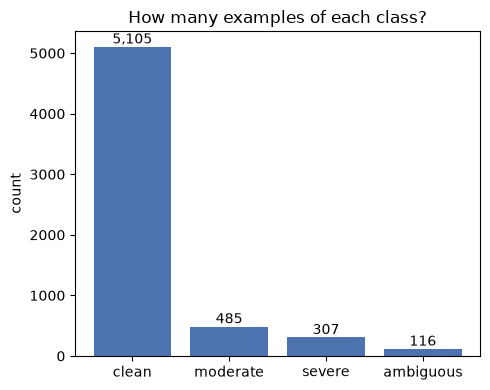

In [4]:
counts = labels_df["class"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(CLASS_NAMES, [counts.get(i, 0) for i in range(1, NUM_CLASSES + 1)], color="#4C72B0")
ax.set_ylabel("count")
ax.set_title("How many examples of each class?")
for i in range(NUM_CLASSES):
    ax.text(i, counts.get(i + 1, 0), f"{counts.get(i + 1, 0):,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

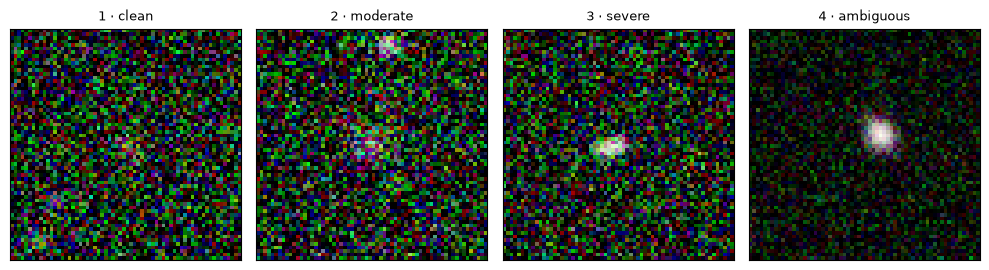

In [5]:
def to_rgb(img):
    # (3, H, W) in band order g, r, i -> HxWx3 RGB for display (i/r/g -> R/G/B), arcsinh-stretched
    g, r, i = img[0], img[1], img[2]
    rgb = np.stack([i, r, g], axis=-1)
    scale = np.percentile(rgb, 99.5)
    scale = scale if scale > 0 else 1.0
    stretched = np.arcsinh(rgb / (scale / 3))
    return np.clip(stretched / stretched.max(), 0, 1) if stretched.max() > 0 else stretched


images_arr = np.load(os.path.join(DATA_DIR, "images.npy"), mmap_mode="r")

rng = np.random.RandomState(CONFIG["seed"])
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(10, 3))
for ax, cls in zip(axes, range(1, NUM_CLASSES + 1)):
    idx = rng.choice(labels_df.index[labels_df["class"] == cls])
    ax.imshow(to_rgb(np.asarray(images_arr[idx], dtype=np.float32)))
    ax.set_title(f"{cls} · {CLASS_NAMES[cls - 1]}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 4. Train / validation split, and normalization

We split by **scene**, not by row: cutouts from the same scene share a sky-noise
realization, so if one ended up in training and another in validation, the model could
"cheat" by recognizing the noise pattern rather than the galaxy. `scene_split` handles
that. `compute_norm_stats` computes a per-band brightness stretch from the training
set only, so validation never leaks into how we normalize inputs.

In [6]:
train_idx, val_idx = scene_split(labels_df, val_frac=CONFIG["val_frac"], seed=CONFIG["seed"])
print(f"train: {len(train_idx):,} cutouts, val: {len(val_idx):,} cutouts")

stats = compute_norm_stats(DATA_DIR, train_idx, seed=CONFIG["seed"])

train: 4,816 cutouts, val: 1,197 cutouts


## 5. Datasets and loaders

`BlendCutoutDataset` reads a cutout, normalizes it with the stats above, and (if
`use_augmentation` is on) applies a random flip/rotation — galaxy orientation on the
sky is arbitrary, so this is free extra training data, not a distortion.

The classes are heavily imbalanced (mostly "clean"). If `use_class_weighting` is on,
`train_loader` uses a *weighted sampler* that draws rare classes more often, so a
typical batch has a more even mix instead of being almost all "clean" — without this,
the model barely ever sees a gradient update that involves "ambiguous" at all.

In [7]:
train_ds = BlendCutoutDataset(DATA_DIR, indices=train_idx, stats=stats, augment=CONFIG["use_augmentation"])
val_ds = BlendCutoutDataset(DATA_DIR, indices=val_idx, stats=stats)

if CONFIG["use_class_weighting"]:
    sample_weights = class_sample_weights(labels_df, train_idx)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)

## 6. Build the network

A standard small CNN: `num_conv_blocks` stacked (conv -> batchnorm -> relu -> 2x2 pool)
blocks, each one halving the image size and doubling the number of filters, followed by
a small fully-connected head that outputs a score for each of the 4 classes.

Try changing `num_conv_blocks` or `base_channels` in Section 1 and re-running from here
— the network below is built directly from those settings, so you'll see the parameter
count and the results change.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, n_bands, num_classes, num_conv_blocks=3, base_channels=16,
                 fc_hidden=64, dropout=0.3, input_size=64):
        super().__init__()
        blocks = []
        in_ch = n_bands
        out_ch = base_channels
        spatial = input_size
        for _ in range(num_conv_blocks):
            assert spatial >= 2, "too many conv blocks for a 64x64 image -- try fewer"
            blocks += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ]
            in_ch = out_ch
            out_ch = out_ch * 2
            spatial = spatial // 2
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch * spatial * spatial, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))

In [9]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"using device: {device}")

torch.manual_seed(CONFIG["seed"])
model = SimpleCNN(
    n_bands=n_bands,
    num_classes=NUM_CLASSES,
    num_conv_blocks=CONFIG["num_conv_blocks"],
    base_channels=CONFIG["base_channels"],
    fc_hidden=CONFIG["fc_hidden"],
    dropout=CONFIG["dropout"],
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"model has {n_params:,} trainable parameters")
model

using device: mps
model has 286,276 trainable parameters


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    

## 7. Train

Standard supervised training loop: for each batch, compute predictions, compute the
loss against the true labels, and update the network's weights to reduce that loss.
We also clip gradients to `grad_clip` before each update — without it, an unlucky
batch (especially likely here, with a rare class this scarce) can produce a huge
gradient that knocks the weights somewhere bad and destabilizes training for several
epochs afterward. We track both training and validation loss/accuracy every epoch —
watching them diverge (train improving, val flat or worsening) is how you spot
overfitting.

Expect the *validation* curve to look noisy from epoch to epoch even once training is
working well — the rare classes have only a few dozen validation examples, so a couple
of lucky or unlucky predictions swing the numbers a lot. Judge it by the overall trend
over several epochs, not any single epoch. The *training* curve, over thousands of
examples, should be much smoother — if that one is jumping around too, something's
actually wrong (try a smaller `learning_rate` first).

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    running_loss, running_correct, n = 0.0, 0, 0
    for images, lbls in train_loader:
        images, lbls = images.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        running_correct += (logits.argmax(1) == lbls).sum().item()
        n += images.size(0)
    train_loss, train_acc = running_loss / n, running_correct / n

    model.eval()
    val_loss, val_correct, n_val = 0.0, 0, 0
    with torch.no_grad():
        for images, lbls in val_loader:
            images, lbls = images.to(device), lbls.to(device)
            logits = model(images)
            loss = criterion(logits, lbls)
            val_loss += loss.item() * images.size(0)
            val_correct += (logits.argmax(1) == lbls).sum().item()
            n_val += images.size(0)
    val_loss, val_acc = val_loss / n_val, val_correct / n_val

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(f"epoch {epoch:2d}/{CONFIG['epochs']}  train_loss {train_loss:.4f}  train_acc {train_acc:.3f}"
          f"  val_loss {val_loss:.4f}  val_acc {val_acc:.3f}")

epoch  1/15  train_loss 1.3554  train_acc 0.330  val_loss 1.3481  val_acc 0.176


epoch  2/15  train_loss 1.2629  train_acc 0.381  val_loss 1.2539  val_acc 0.506


epoch  3/15  train_loss 1.2055  train_acc 0.423  val_loss 0.9957  val_acc 0.809


epoch  4/15  train_loss 1.1592  train_acc 0.439  val_loss 1.1594  val_acc 0.459


epoch  5/15  train_loss 1.1108  train_acc 0.464  val_loss 0.9258  val_acc 0.811


...

epoch 11/15  train_loss 0.9333  train_acc 0.545  val_loss 1.0330  val_acc 0.251


epoch 12/15  train_loss 0.9173  train_acc 0.570  val_loss 1.1524  val_acc 0.477


epoch 13/15  train_loss 0.8875  train_acc 0.584  val_loss 0.8734  val_acc 0.642


epoch 14/15  train_loss 0.8766  train_acc 0.590  val_loss 0.9335  val_acc 0.674


epoch 15/15  train_loss 0.8472  train_acc 0.606  val_loss 0.8035  val_acc 0.689


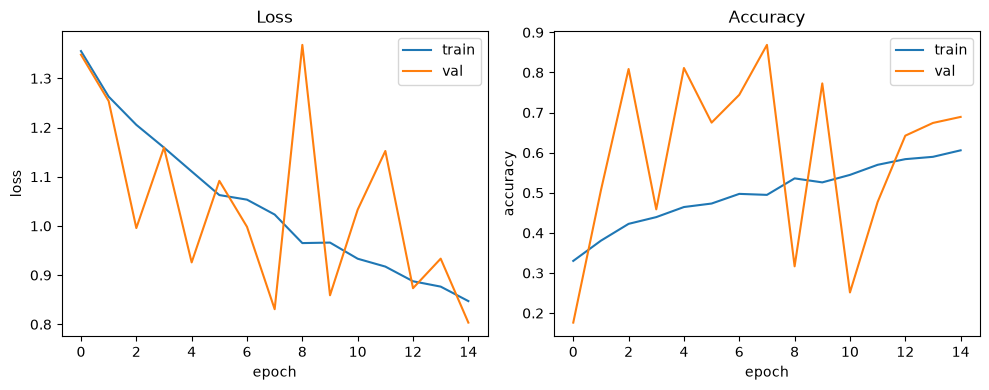

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate

Overall accuracy is misleading here because the classes are so imbalanced — a model
that just always predicts "clean" would score ~85% accuracy while being useless. Two
better metrics:

- **Balanced accuracy**: average of the per-class recalls, so every class counts
  equally regardless of how common it is.
- **Quadratic weighted kappa (QWK)**: since the classes are ordered (clean < moderate
  < severe < ambiguous), this penalizes a clean/ambiguous mistake much more than a
  clean/moderate one. It's the metric the main project pipeline optimizes for, using a
  more advanced ordinal-regression loss (CORN) instead of the plain cross-entropy loss
  used here — worth reading about once this basic version makes sense to you.

In [12]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, lbls in val_loader:
        logits = model(images.to(device))
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(lbls.numpy())
preds = np.concatenate(all_preds)
targets = np.concatenate(all_targets)

bal_acc = balanced_accuracy_score(targets, preds)
qwk = cohen_kappa_score(targets, preds, weights="quadratic")
print(f"balanced accuracy: {bal_acc:.3f}")
print(f"quadratic weighted kappa (QWK): {qwk:.3f}")
print()
print(classification_report(targets, preds, target_names=CLASS_NAMES, digits=2))

balanced accuracy: 0.493
quadratic weighted kappa (QWK): 0.452

              precision    recall  f1-score   support

       clean       0.94      0.74      0.82      1029
    moderate       0.11      0.37      0.17        84
      severe       0.29      0.45      0.35        65
   ambiguous       0.47      0.42      0.44        19

    accuracy                           0.69      1197
   macro avg       0.45      0.49      0.45      1197
weighted avg       0.84      0.69      0.75      1197



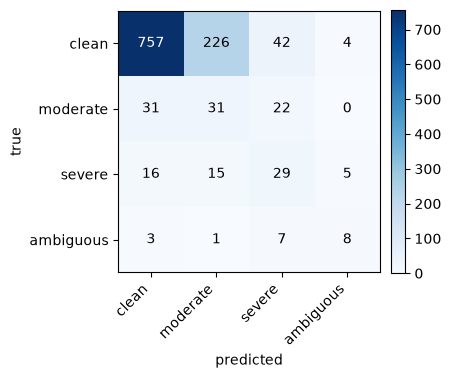

In [13]:
cm = confusion_matrix(targets, preds, labels=range(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
thresh = cm.max() / 2
for r in range(NUM_CLASSES):
    for c in range(NUM_CLASSES):
        ax.text(c, r, cm[r, c], ha="center", va="center", color="white" if cm[r, c] > thresh else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

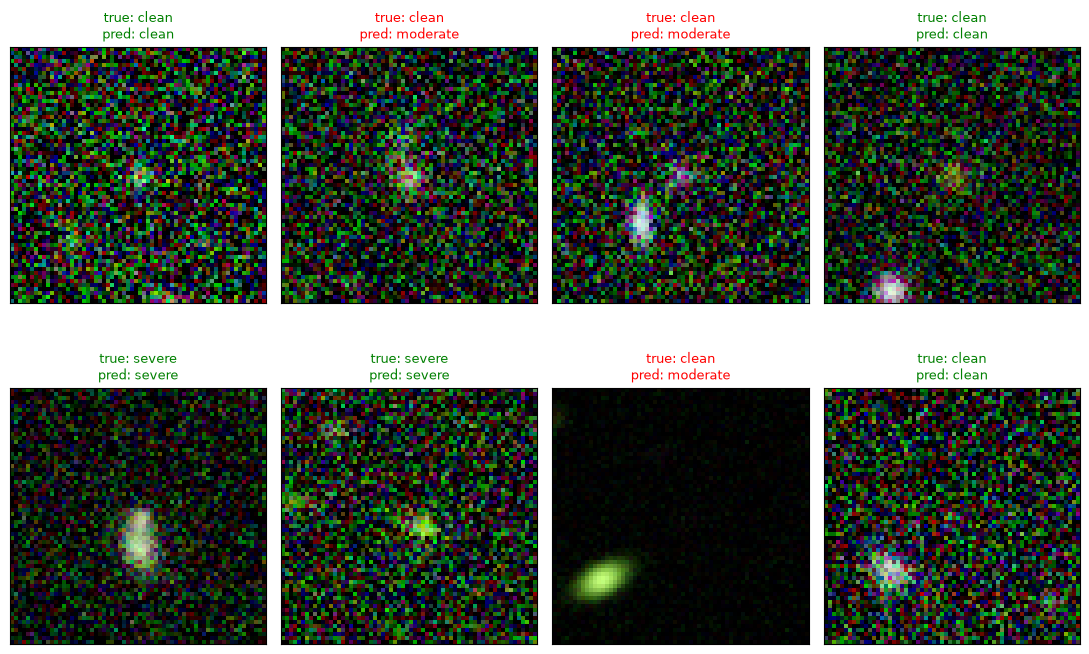

In [14]:
rng2 = np.random.RandomState(1)
sample_positions = rng2.choice(len(val_idx), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(11, 7))
for ax, pos in zip(axes.flat, sample_positions):
    img_tensor, true_label = val_ds[pos]
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        pred_label = logits.argmax(1).item()
    raw_img = np.asarray(images_arr[val_idx[pos]], dtype=np.float32)
    ax.imshow(to_rgb(raw_img))
    correct = pred_label == true_label
    ax.set_title(f"true: {CLASS_NAMES[true_label]}\npred: {CLASS_NAMES[pred_label]}",
                 fontsize=9, color="green" if correct else "red")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout(h_pad=3)
plt.show()

## 9. Things to try

Go back to the **Settings** cell (Section 1), change one setting at a time, and
re-run from that cell down. Some things worth trying, and what to watch for:

- **`num_conv_blocks`** (try 2 vs 4): does a deeper network do better, or does it start
  overfitting (train accuracy high, val accuracy flat/worse)?
- **`base_channels`** (try 8, 16, 32): a wider network has more capacity but also more
  parameters to overfit with a small dataset — watch the parameter count printed in
  Section 6.
- **`use_class_weighting`** (try `False`): watch what happens to the `severe` and
  `ambiguous` rows in the confusion matrix specifically -- without oversampling, the
  model may barely predict them at all.
- **`use_augmentation`** (try `False`): does train accuracy pull further ahead of val
  accuracy?
- **`learning_rate`** (try `1e-2` and `1e-4`): too high can make the loss curve noisy
  or diverge; too low can make training barely move in 15 epochs.
- **`grad_clip`** (try `0.1` and `100`): a very small value slows learning (every
  update gets capped); a very large one effectively disables clipping -- watch the
  val accuracy curve get noisier if training was borderline unstable to begin with.
- **`epochs`** (try 40): does val loss keep improving, or does it bottom out and start
  rising while train loss keeps dropping (classic overfitting)?
- **`dropout`** (try 0.0 vs 0.5): how does it affect the train/val accuracy gap?

After experimenting, look at the confusion matrix and the example predictions grid —
do the mistakes make sense given what the class examples in Section 3 look like?